# Movie Success Prediction
## Notebook 03 — Statistical Correlation Analysis
**Dataset:** `movies_cleaned.xlsx` — 5,475 movies · 20 columns · 1980–2020

---

## STEP 1 — Install & Import Libraries

In [ ]:
# Install openpyxl if needed (required to read .xlsx in Colab)
!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import (pearsonr, spearmanr, pointbiserialr,
                          mannwhitneyu, kruskal, chi2_contingency)
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

print('Libraries ready')

Libraries ready


## STEP 2 — Load the Dataset


In [ ]:
# Load the dataset
df = pd.read_excel('/movies_cleaned.xlsx')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (5475, 20)
Columns: ['Unnamed: 0', 'name', 'rating', 'genre', 'year', 'released', 'score', 'votes', 'director', 'writer', 'star', 'country', 'budget', 'gross', 'company', 'runtime', 'release_month', 'release_day', 'roi', 'roi_class']


,Unnamed: 0,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,release_month,release_day,roi,roi_class
0,1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,7,2,13.078468,blockbuster
1,2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,6,20,29.909726,blockbuster
2,3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,7,2,23.843868,blockbuster
3,4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,7,25,6.641057,blockbuster
4,5,Friday the 13th,R,Horror,1980,"May 9, 1980 (United States)",6.4,123000.0,Sean S. Cunningham,Victor Miller,Betsy Palmer,United States,550000.0,39754601.0,Paramount Pictures,95.0,5,9,72.281093,blockbuster


## STEP 3 — Preprocessing for Analysis
We engineer a few extra columns and create a **binary hit flag** for point-biserial and hypothesis tests.


Please explain this

In [ ]:
df2 = df.copy()

# ── Log-transform skewed columns (budget, gross, votes are heavily right-skewed)
df2['log_budget'] = np.log1p(df2['budget'])
df2['log_gross']  = np.log1p(df2['gross'])
df2['log_votes']  = np.log1p(df2['votes'])
df2['log_roi']    = np.log1p(df2['roi'].clip(lower=0))

# ── Profit
df2['profit'] = df2['gross'] - df2['budget']

# ── Decade
df2['decade'] = (df2['year'] // 10 * 10).astype(str) + 's'

# ── Binary hit: blockbuster OR hit in roi_class
df2['is_hit'] = df2['roi_class'].isin(['hit', 'blockbuster']).astype(int)

# ── Clean rating: keep 4 main categories
df2['rating_clean'] = df2['rating'].where(
    df2['rating'].isin(['G','PG','PG-13','R']), 'Other')

# ── Encode roi_class as ordered integer for correlation
roi_order = {'flop': 0, 'below_avg': 1, 'hit': 2, 'blockbuster': 3}
df2['roi_class_num'] = df2['roi_class'].map(roi_order)

hit_rate = df2['is_hit'].mean() * 100
print(f'Rows           : {len(df2)}')
print(f'Hit rate       : {hit_rate:.1f}%  ({df2["is_hit"].sum()} hits out of {len(df2)})')
print(f'Log columns added: log_budget, log_gross, log_votes, log_roi')
print(f'New columns    : profit, decade, is_hit, rating_clean, roi_class_num')

Rows           : 5475
Hit rate       : 55.2%  (3022 hits out of 5475)
Log columns added: log_budget, log_gross, log_votes, log_roi
New columns    : profit, decade, is_hit, rating_clean, roi_class_num


## STEP 4 — Spearman Correlation Heatmap (All Numeric Features)

Measures the strength and direction of relationships between numerical variables using ranked value.


Why is it used?

Movie variables like budget, gross, votes, and ROI are highly skewed with outliers, so Spearman is more reliable for this dataset.


What are we doing?

We calculate correlations between major movie features to identify which variables are strongly related to each other and to movie success.

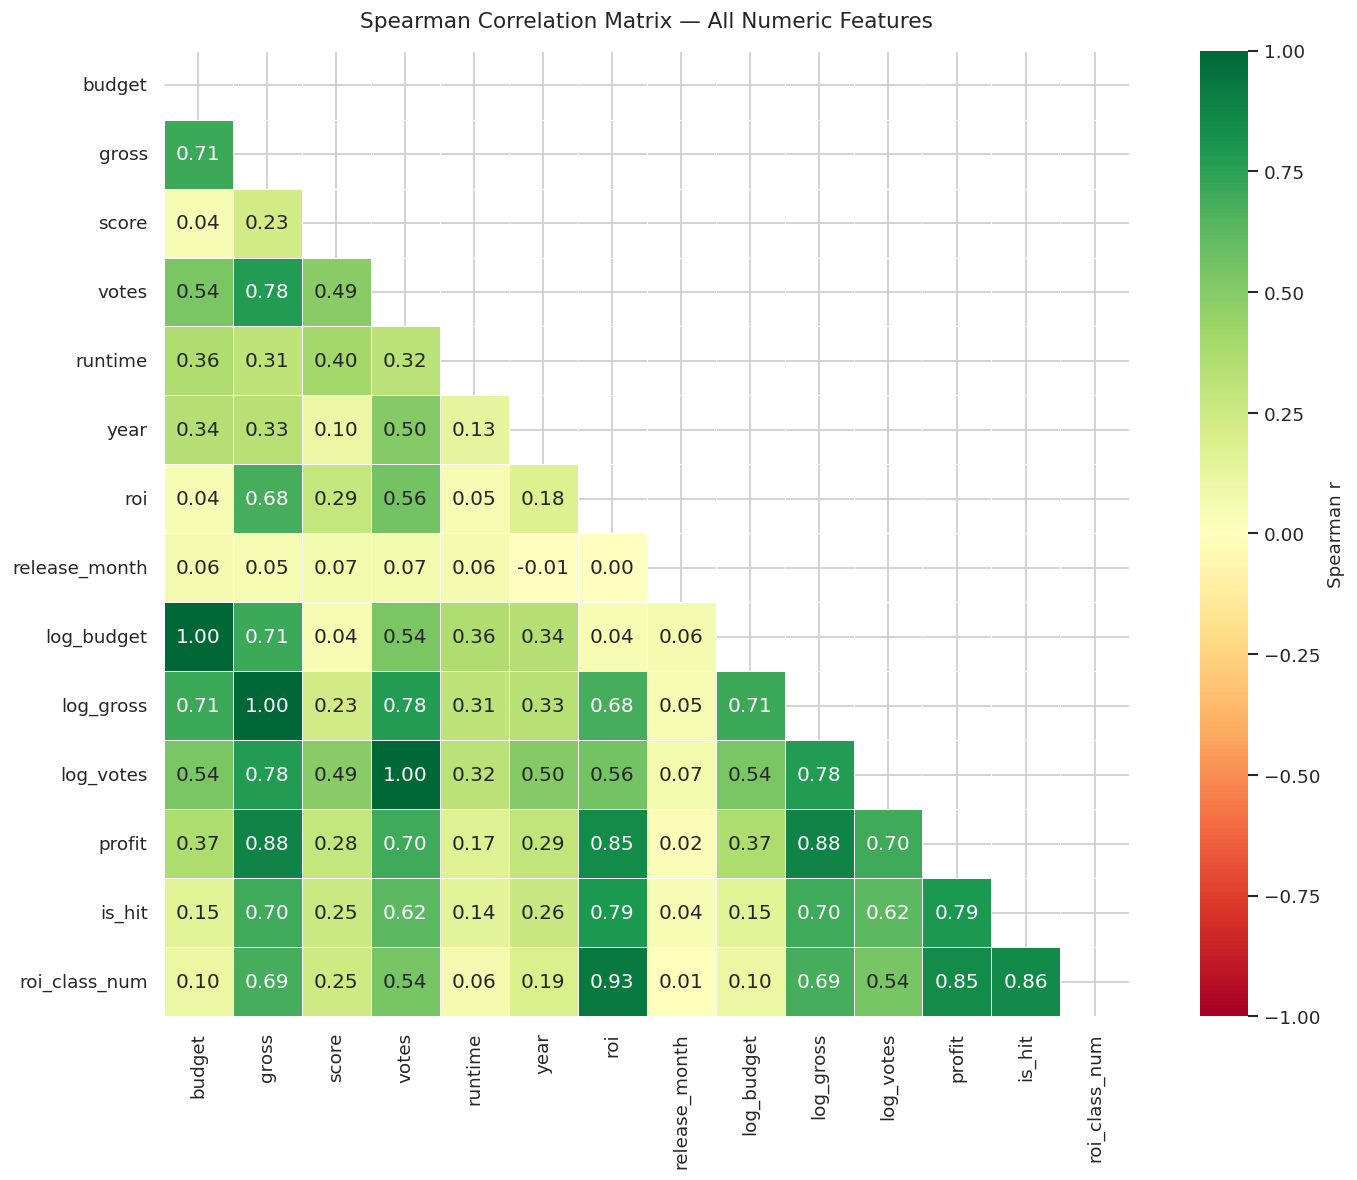


🔍 Strongest correlations (|r| > 0.35, excluding self/log duplicates):
    Feature A  Feature B  Spearman r
   log_budget     budget    1.000000
    log_gross      gross    1.000000
    log_votes      votes    1.000000
roi_class_num        roi    0.929313
       profit      gross    0.879636
       profit  log_gross    0.879636
roi_class_num     is_hit    0.855260
roi_class_num     profit    0.848125
       profit        roi    0.846267
       is_hit        roi    0.794804
       is_hit     profit    0.794804
    log_votes      gross    0.780312
    log_votes  log_gross    0.780312
        votes      gross    0.780312
    log_gross      votes    0.780312
        gross     budget    0.709754
    log_gross     budget    0.709754
   log_budget      gross    0.709754
    log_gross log_budget    0.709754
       is_hit      gross    0.699502
       is_hit  log_gross    0.699502
       profit  log_votes    0.696698
       profit      votes    0.696698
roi_class_num      gross    0.685372
roi_

In [ ]:
num_cols = ['budget','gross','score','votes','runtime','year',
            'roi','release_month','log_budget','log_gross',
            'log_votes','profit','is_hit','roi_class_num']

corr = df2[num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4,
            cbar_kws={'label': 'Spearman r'}, ax=ax)

ax.set_title('Spearman Correlation Matrix — All Numeric Features', pad=14)
plt.tight_layout()
plt.savefig('heatmap_all_features.png', bbox_inches='tight')
plt.show()

# Print the strongest pairs
print('\n🔍 Strongest correlations (|r| > 0.35, excluding self/log duplicates):')
pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
             .stack()
             .reset_index())
pairs.columns = ['Feature A','Feature B','Spearman r']
strong = pairs[pairs['Spearman r'].abs() > 0.35].sort_values('Spearman r', ascending=False)
print(strong.to_string(index=False))

#Interpretation of Outputs

Budget vs Gross (r = 0.71): Higher-budget movies generally earn higher revenue.

Votes vs Gross (r = 0.78): More popular movies tend to generate higher revenue.

ROI vs is_hit (r = 0.79): More profitable movies are more likely to be hits.

Score vs Votes (r = 0.49): Higher-rated movies usually receive more audience engagement.

Release Month (r ≈ 0): Release timing has very weak influence on success.

Strongest Correlation Table: Financial performance, popularity, and profitability show the strongest relationships with movie success.

Overall Insight

Movie success is most strongly associated with audience engagement, revenue generation, and profitability, while factors like release month and runtime have weaker influence.

## STEP 5 — Feature Correlation with Movie Success (`is_hit`)

Measures how strongly each feature is related to movie success (is_hit) using Spearman correlation.


Why is it used?

It helps identify which variables are most associated with a movie becoming a hit.

What are we doing?

We calculate the correlation between each feature and the binary success variable (is_hit) and visualize the relationships using a bar chart.


doubt: should we remove roi and profit? as we need to predict if the movie will be hit or not



#Important Note

roi_class_num should be removed because is_hit is already derived from ROI class, which creates target leakage.

profit and roi can also be removed if the goal is early prediction, since they depend on post-release financial performance.

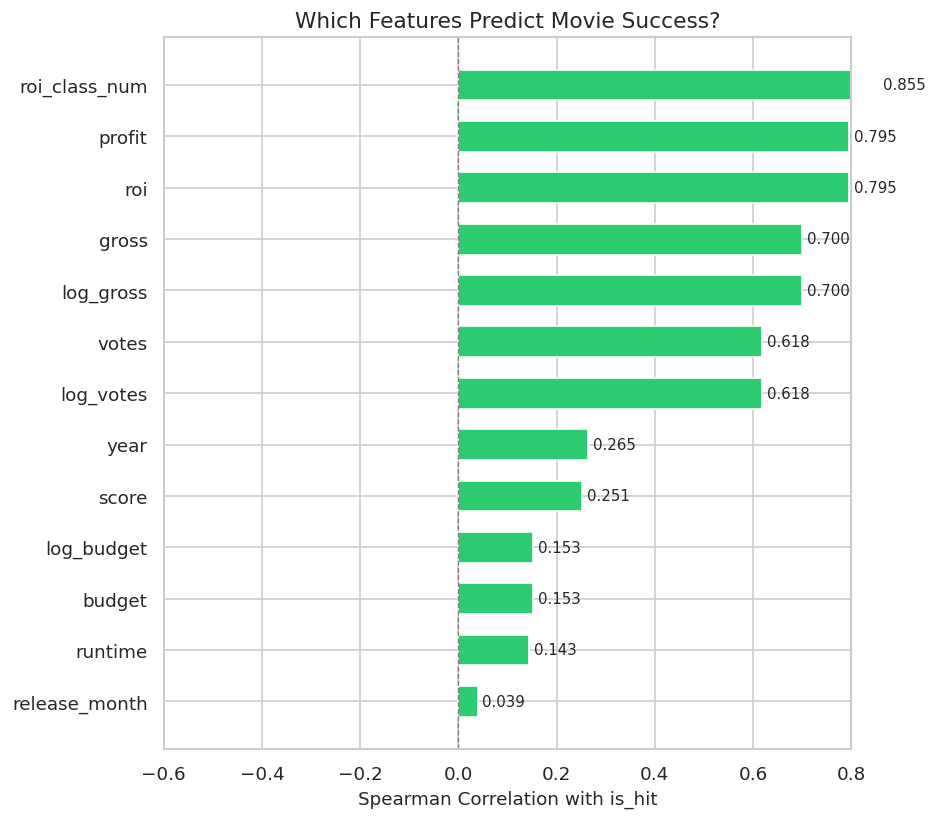


📌 Interpretation:
  Green bars → positively correlated with success (higher = more likely to be a hit)
  Red bars   → negatively correlated (higher = less likely to be a hit)


In [ ]:
hit_corr = corr['is_hit'].drop('is_hit').sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in hit_corr]
bars = ax.barh(hit_corr.index, hit_corr.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')

# Add value labels
for bar, val in zip(bars, hit_corr.values):
    xpos = val + 0.01 if val >= 0 else val - 0.01
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

ax.set_xlabel('Spearman Correlation with is_hit')
ax.set_title('Which Features Predict Movie Success?')
ax.set_xlim(-0.6, 0.8)
plt.tight_layout()
plt.savefig('feature_vs_hit.png', bbox_inches='tight')
plt.show()

print('\n📌 Interpretation:')
print('  Green bars → positively correlated with success (higher = more likely to be a hit)')
print('  Red bars   → negatively correlated (higher = less likely to be a hit)')

#Interpretation of Outputs

Gross / log_gross (r ≈ 0.70): Movies earning higher revenue are more likely to be hits.

Votes / log_votes (r ≈ 0.62): Audience engagement strongly relates to movie success.

Score (r ≈ 0.25): Better-rated movies have a moderate success relationship.

Budget (r ≈ 0.15): Bigger budgets help, but alone are not strong predictors.

Release Month (r ≈ 0.04): Release timing has very little influence on success.

#Overall Insight

Audience popularity, revenue generation, and financial performance show the strongest relationship with movie success, while factors like release month and runtime contribute much less.

## STEP 6 — Chi-Square Test: Genre × ROI Class

Chi-square tests whether **two categorical variables are independent**.  
Here: Is success class (flop/hit/blockbuster) dependent on genre?

Checks whether two categorical variables are statistically associated or independent.

Why is it used?

It helps determine whether movie success categories (flop, hit, blockbuster) depend on genre.

What are we doing?

We compare genres with ROI-based success classes to check whether some genres consistently perform better or worse than others.

Contingency Table (Genre × ROI Class):
roi_class  below_avg  blockbuster  flop  hit
genre                                       
Action           154          552   147  297
Adventure         35          119    39   36
Animation         11          156    11   36
Biography         31           83    40   52
Comedy           198          628   218  269
Crime             50          119    82   61
Drama             96          299   135  100
Horror            17          143    21   25

Chi-square statistic : 170.816
Degrees of freedom   : 21
p-value              : 1.7914e-25
Result               : ✅ Genre and ROI class are NOT independent


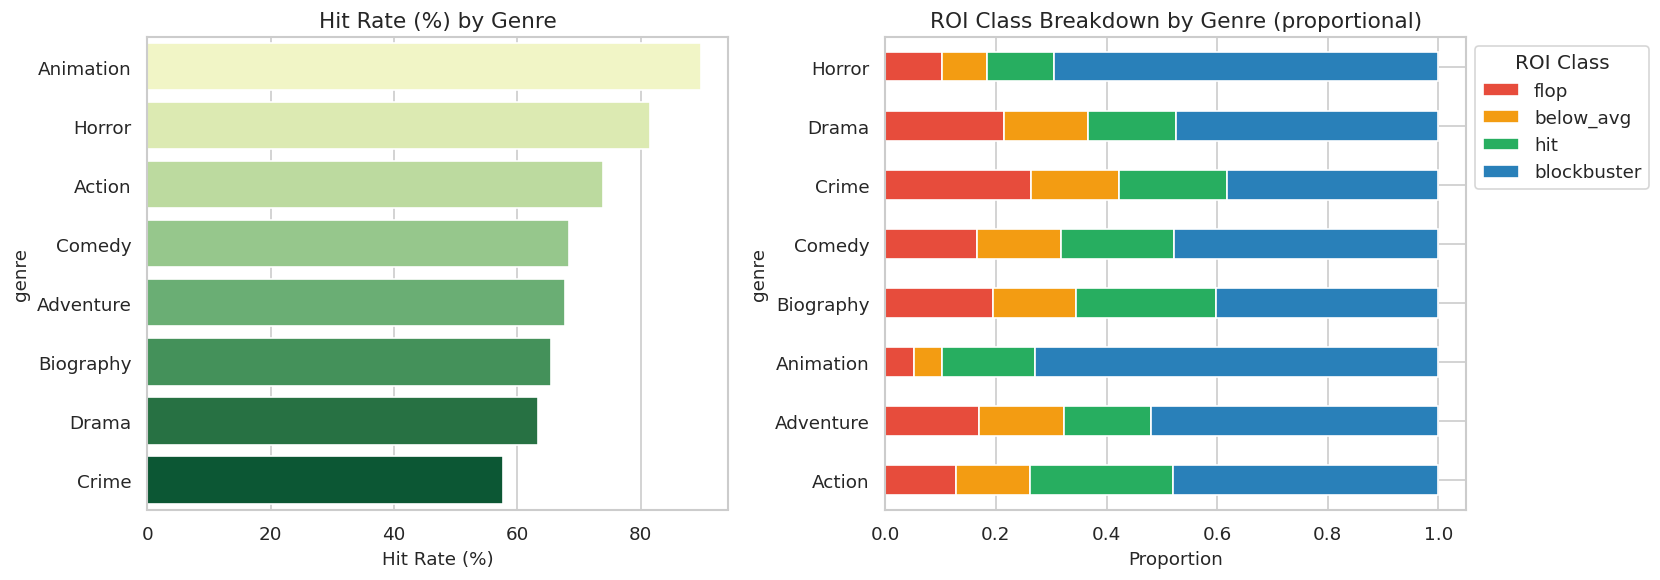

In [ ]:
# Filter to genres with ≥ 50 movies
top_genres = df2['genre'].value_counts()
top_genres = top_genres[top_genres >= 50].index.tolist()
df_chi = df2[df2['genre'].isin(top_genres)].dropna(subset=['roi_class'])

# Contingency table: genre × roi_class
contingency = pd.crosstab(df_chi['genre'], df_chi['roi_class'])
print('Contingency Table (Genre × ROI Class):')
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)
print(f'\nChi-square statistic : {chi2:.3f}')
print(f'Degrees of freedom   : {dof}')
print(f'p-value              : {p:.4e}')
print(f'Result               : {"✅ Genre and ROI class are NOT independent" if p < 0.05 else "❌ No significant relationship"}')

# Heatmap of hit rates per genre
hit_rate_genre = (
    df_chi.groupby('genre')['is_hit'].mean() * 100
).sort_values(ascending=False).reset_index()
hit_rate_genre.columns = ['genre','hit_rate_pct']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=hit_rate_genre, x='hit_rate_pct', y='genre',
            palette='YlGn', ax=axes[0])
axes[0].set_title('Hit Rate (%) by Genre')
axes[0].set_xlabel('Hit Rate (%)')

# Stacked bar: ROI class breakdown per genre
prop = contingency.div(contingency.sum(axis=1), axis=0)
prop = prop[['flop','below_avg','hit','blockbuster']]
prop.plot(kind='barh', stacked=True, color=['#e74c3c','#f39c12','#27ae60','#2980b9'],
          ax=axes[1])
axes[1].set_title('ROI Class Breakdown by Genre (proportional)')
axes[1].set_xlabel('Proportion')
axes[1].legend(title='ROI Class', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.savefig('chi_square_genre.png', bbox_inches='tight')
plt.show()

#Interpretation of Outputs
P-value = 1.79e-25 (< 0.05): Genre and ROI class are statistically associated and not independent.

Animation & Horror: These genres show the highest hit/blockbuster proportions.

Crime & Drama: These genres have relatively lower hit rates and more flop/below-average movies.

Stacked ROI Breakdown: The success distribution differs clearly across genres, showing that genre influences movie performance patterns.

#Overall Insight

Movie success varies significantly across genres, indicating that genre plays an important role in influencing a movie’s probability of becoming a flop, hit, or blockbuster.